# Applied Math 10: Computing for Science and Engineering

## Lab 09 : First-order Ordinary Differential Equations (ODEs)

**Fall 2020**<br/>
<br>


### Learning Goals of Lab 
In this Lab, we continue the work started in Lecture 9. The objective is to:

- write python functions for methods of solving first order ODEs discussed in the class
- solve ODEs 
- solve the system of equations of the SIR epidemic model

___________________________________________________________________________________________________________________________

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## Functions for Euler and modified Euler methods

We will start by writing functions for the methods discussed in lecture 9 generalizing the methods to a broader class of functions, i.e.
$$ \frac{du}{dx} = f(x,u) $$

where $f(x,u)$ can be changed without modifying the core of the integration routine. 

### Function for the Euler method:

From Lecture 9, we emphasize that:
$$ 
u(x_{n+1}) = u(x_n) + \Delta x \cdot f(u(x_n), x_n)$$

In [3]:
def euler(Nx, xmin, xmax, uf0):
    #Diff eqn of form: d(uf)/dx=ff(x,uf) 
    #Nx: Number of points to be used for integration
    #xmin, xmax: Initial and final values of the independent variable (x)
    #uf0: Initial value of the dependent variable at x=xmin
    
    #Assume the function f(u,x) is of form:
    
    #ff(x[n], uf[n])
    
    #For any function f(u,x) on the RHS, you need to provide (define it outside of this euler() function, in a separate cell)
    #a python function. For example, for the eigenfunction problem:
    
    #def ff(x, y):
    #    a=2.0
    #    dydx = a * y
    #    return dydx
    
    #Define x
    x = np.linspace(xmin, xmax, Nx)
    #Calculate dx
    dx = x[1] - x[0]
    #Set up the array for ux
    uf = np.zeros(Nx)
    #Define the initial condition
    uf[0] = uf0
    
    #We need to write another function ff(x[n],uf[n])
    #for the integrand. We will do it later when we need to
    #solve the equation for particular cases.
    for n in range(Nx - 1):
        #Fill in the code for uf[n+1]
        #--------------------------------------
        uf[n+1] = uf[n] + dx * ff(x[n], uf[n])
        #--------------------------------------
    return uf

### Function for the modified-Euler method
Again the formula for the modified-Euler method is:
$$u_{n+1} = u_n + \frac{1}{2} \Delta x \left \{ f(x_n, u_n) + f(x_{n+1}, u_n+\Delta x \cdot f(x_n, u_n) ) \right \}$$

In [4]:
def mod_euler(Nx, xmin, xmax, uf0):
    #Diff eqn of form: d(uf)/dx=ff(x,uf)
    #Nx: Number of points to be used for integration
    #xmin, xmax: Initial and final values of the independent variable (x)
    #uf0: Initial value of the dependent variable at x=xmin
     
    #Define x
    x = np.linspace(xmin, xmax, Nx)
    #Determine dx
    dx = x[1] - x[0]
    #Set up the array for ux and initialize it to zero
    uf = np.zeros(Nx)
    #Specify the boundary (initial) condition at x=xmin
    uf[0] = uf0

    for n in range(Nx - 1):
        # uf[n+1] is of the form: uf[n+1] = uf[n] + 0.5 * dx * (ff1 + ff2)
        #Write in the code for ff1 and ff2
        #--------------------------------------
        ff1 = ff(x[n], uf[n])
        ff2 = ff(x[n+1], uf[n] + dx * ff(x[n], uf[n]))
        #--------------------------------------------
        uf[n+1] = uf[n] + 0.5 * dx * (ff1 + ff2)
    return uf

## Example 

Solve the problem:

$$ \frac{du}{dx} = a u $$

over the domain $0 \le x \le 3$. Here, $a=-50.0$ and $u(0)=1.0$.

Try Nx=100. Use the functions you wrote for Euler and  modified-Euler methods. Plot the solutions.

The exact solution is $u(x) = A e^{ax}$.

In [52]:
# Define the function f (RHS of the differential equation -- f(x,u))
# will be named ff, as seen below

#-----------------------------
def ff(x,y):
    #a=2.0
    a=-50
    dydx=a*y
    return dydx
#--------------------------

In [55]:
#Generating the x points and the exact solution

Nx=100
xmin=0.0
xmax=3.0
x = np.linspace(xmin, xmax, Nx)

a=-50
Afact=1.0
utrue = Afact * np.exp(a * x)

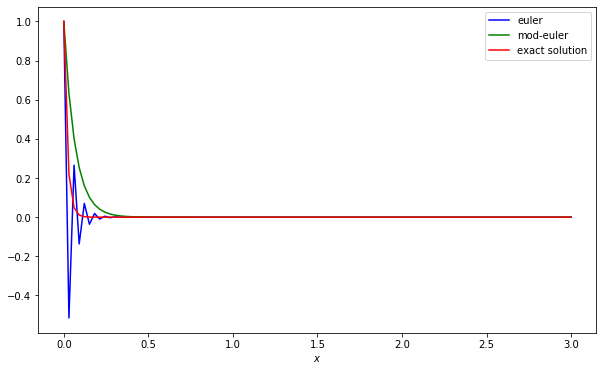

In [56]:
# Apply Euler's method to the eigenfunction problem

# Prepare the arguments for the Euler and modified-Euler
# function calls and call the functions

#---------------------------
uf0=Afact

uf1 = euler(Nx, xmin, xmax, uf0)
uf2 = mod_euler(Nx, xmin, xmax, uf0)
#--------------------------------------

plt.figure(figsize=(10,6))

plt.plot(x, uf1, 'b-',label="euler")
plt.plot(x, uf2, 'g-',label="mod-euler")

plt.plot(x, utrue, 'r-', label="exact solution")
plt.xlabel('$x$')
plt.legend()
plt.show()


As can be seen, Euler's method can become unstable. A larger Nx number is needed to achieve a better approximate solution. 

__________________________________________________________________________________________________________________________

## Team Activity 1: (link to your team's breakout room)

## Problem 1

Solve the following ODE:

\begin{equation}
\frac{dn}{dt} = rn(1-\frac{n}{N}) \hspace{6cm} (1)
\end{equation}

over the domain $0 \le t \le 30$. Here,  $r=0.5$, $N=10$, and $n(t=0)=n_0=0.001$.
Plot the solutions and compare them to the exact solution (see below)  with the Euler's and the modified Euler's methods.

   This problem has the following function as the exact solution:
   \begin{equation}
    n(t)=\frac{N}{1+\left[\frac{N}{n_0}-1\right]e^{-rt}} \hspace{6cm} (2)
   \end{equation}
   

In [8]:
# your code here


**Return to main room**

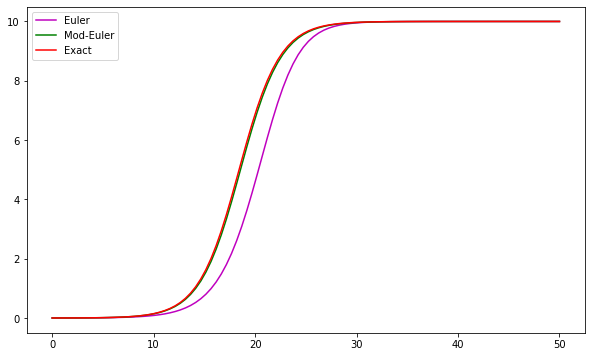

In [44]:
#Solution to problem 1

Nx=100

xmin = 0
xmax = 50.0

#Initial condition 

uf00 = 0.001 #initial condition
r = 0.5
N = 10

#Function to be integrated
def ff(x,y):
    dydx = r*y*(1-y/N)
    return dydx

x = np.linspace(xmin, xmax, Nx)

#Exact solution (initial condition uf00=0.001
utrue10 = N/(1+(N/uf00-1)*np.exp(-r*x))

#Find the solution for initial condition uf00

uf10 = euler(Nx, xmin, xmax, uf00)
uf20 = mod_euler(Nx, xmin, xmax, uf00)

    
plt.figure(figsize=(10,6))    
    
plt.plot(x, uf10, 'm-',label="Euler")
plt.plot(x, uf20, 'g-',label="Mod-Euler")

plt.plot(x, utrue10, 'r-',label="Exact")

plt.legend(loc='upper left')
plt.show()

As can be seen, Euler's method does not approximate well the exact solution. A larger Nx number is needed to achieve a better approximate solution. 

________________________________________________________________________________________________________________________________

### Applying the SIR epidemic model 

A simple mathematical description of the spread of a disease in a population is the so-called SIR model, which divides the (fixed) population of N individuals into three groups (S, I, R, defined below) which may vary as a function of time, t:

- $S(t)$ susceptible but not yet infected with the disease;
- $I(t)$ infectious individuals;
- $R(t)$ recovered from the disease, now with immunity.

The SIR model involves two parameters, $\beta$ and $\gamma$: 
- $\beta$ describes the effective contact rate of the disease: an infected individual comes into contact with $\beta$ other individuals per unit time (the fraction that are susceptible to contracting the disease is $S/N$); 
- $\gamma$ is the mean recovery rate (equivalently, $\frac{1}{\gamma}$ is the mean period of time during which an infected individual can pass it on).

The differential equations describing this model were first derived by Kermack and McKendrick [Proc. R. Soc. A, 115, 772 (1927)]:

$$ \frac{dI}{dt} = \beta I \frac{S}{N} - \gamma I  $$

$$ \frac{dS}{dt} = - \beta I \frac{S}{N} $$

$$ \frac{dR}{dt} = \gamma I $$

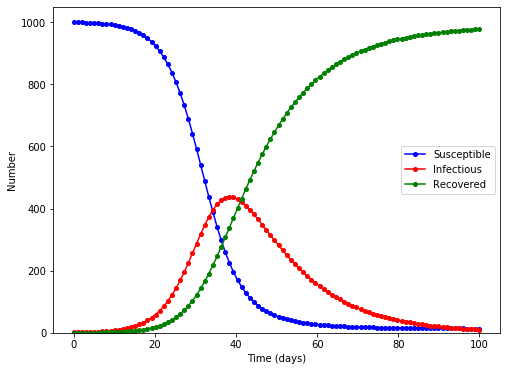

In [10]:
# Total population (N) and number of days (Ndays) of epidemic duration
N = 1000
Ndays=100

# Contact rate, beta, and mean recovery rate, gamma, (in 1/days).
beta = 0.3
gamma = 1.0/14

# Generating the time array:
t = np.linspace(0, Ndays, Ndays)
dt=t[1]-t[0]

# Initializing the S, I, R arrays
S=np.zeros(Ndays)
I=np.zeros(Ndays)
R=np.zeros(Ndays)

# start with one infected individual
S[0]=N
I[0]=1
R[0]=0

# Solving the system of differential equations
for n in range(Ndays-1):
    S[n+1]=S[n]+dt*(-beta*S[n]*I[n]/N)
    I[n+1]=I[n]+dt*(beta*S[n]*I[n]/N - gamma*I[n])
    R[n+1]=R[n]+dt*(gamma*I[n])


# Plotting the result (disease trajectory)
fig=plt.figure(figsize=(8,6))
plt.plot(t,S,'bo-',ms=4,label='Susceptible')
plt.plot(t,I,'ro-',ms=4,label='Infectious')
plt.plot(t,R,'go-',ms=4,label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Number')
plt.ylim(0,01.05*N)
plt.legend(loc='center right')
plt.show()

___________________________________________________________________________________________________________________________

## Team Activity #2: (link to your team's breakout room)

### Problem 2: Explore ways to "flatten the curve" 

"Flatten the curve" is an expression used to denote a more gradual increase in the number of cases per day and a more gradual decrease. This way, it takes longer for a contagious disease to spread, and, as such, the more time hospitals have to prepare and the healthcare system to operate within capacity limits (see schematic below).

One way to "flatten the curve" is to impose social distancing / lockdown measures, that is, decreasing the contact rate (thus decreasing the value of $\beta$).  

Hint: make $\beta$ time-dependent ($\beta (t)$) instead of a constant, and reduce its value(s) after a certain time `t_imp` (choose your own parameter values). Adapt the SIR code accordingly, solve the system of equations, and plot the results (the time evolution of the S, I, R populations). Comment on your results. 

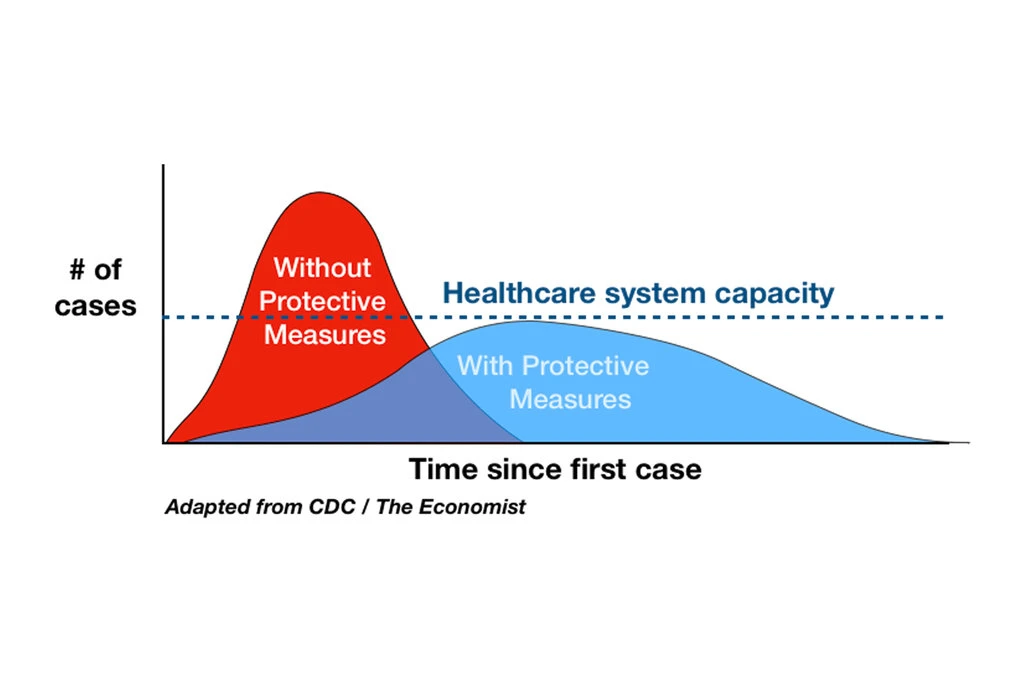

Source: https://www.nytimes.com/article/flatten-curve-coronavirus.html

In [11]:
# your code here


**Return to main room**

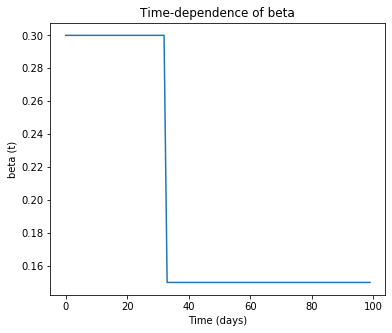

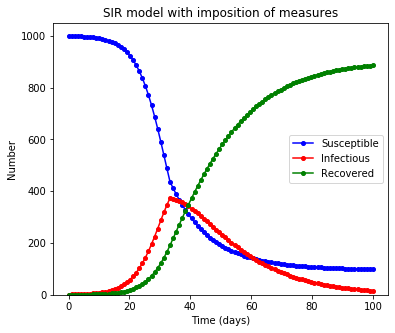

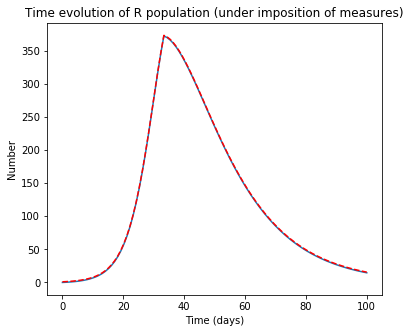

In [58]:
# Solution (making beta time-dependent)

# Total population (N) and number of days (Ndays) of epidemic duration
N = 1000
Ndays=100

# Contact rate, beta, and mean recovery rate, gamma, (in 1/days).
#beta = 0.3
#gamma = 1.0/10

beta = 0.3
gamma = 1.0/14

# Generating the time array:
t = np.linspace(0, Ndays, Ndays)
dt=t[1]-t[0]

# Initializing the S, I, R arrays
S=np.zeros(Ndays)
I=np.zeros(Ndays)
R=np.zeros(Ndays)

mid = int(Ndays/3)

betaC = np.zeros(Ndays)
for i in range(Ndays):
    betaC[i] = beta
for i in range(mid,Ndays):
    betaC[i] = 0.5 * beta

fig=plt.figure(figsize=(6,5))
plt.plot(betaC)
plt.xlabel('Time (days)')
plt.ylabel('beta (t)')
plt.title('Time-dependence of beta')
plt.show()
    
# start with one infected individual

S[0]=N
I[0]=1
R[0]=0

# Solving the system of differential equations
for n in range(Ndays-1):
    S[n+1]=S[n]+dt*(-betaC[n]*S[n]*I[n]/N)
    I[n+1]=I[n]+dt*(betaC[n]*S[n]*I[n]/N - gamma*I[n])
    R[n+1]=R[n]+dt*(gamma*I[n])

    
# Plotting the results
fig=plt.figure(figsize=(6,5))
plt.plot(t,S,'bo-',ms=4,label='Susceptible')
plt.plot(t,I,'ro-',ms=4,label='Infectious')
plt.plot(t,R,'go-',ms=4,label='Recovered')

plt.xlabel('Time (days)')
plt.ylabel('Number')
plt.ylim(0,01.05*N)
plt.legend(loc='center right')
plt.title('SIR model with imposition of measures')
plt.show()
#fig.savefig('SIR_with_measures.pdf',format='pdf')

fig=plt.figure(figsize=(6,5))
plt.plot(t,N-S-R)
plt.plot(t,I,'r--')
plt.xlabel('Time (days)')
plt.ylabel('Number')
plt.title('Time evolution of R population (under imposition of measures)')
plt.show()


__________________________________________________________________________________________________________________________

### Studying Epidemic Waves


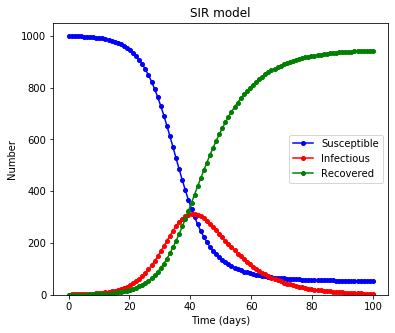

In [24]:
# The SIR model again...
# Total population (N) and number of days (Ndays) of epidemic duration
N = 1000
Ndays=100

# Contact rate, beta, and mean recovery rate, gamma, (in 1/days).
#beta = 0.3
#gamma = 1.0/10

beta = 0.3
gamma = 1/10

# Generating the time array:
t = np.linspace(0, Ndays, Ndays)
dt=t[1]-t[0]

# Initializing the S, I, R arrays
S=np.zeros(Ndays)
I=np.zeros(Ndays)
R=np.zeros(Ndays)
    
# start with one infected individual

S[0]=N
I[0]=1
R[0]=0

# Solving the system of differential equations
for n in range(Ndays-1):
    S[n+1]=S[n]+dt*(-beta*S[n]*I[n]/N)
    I[n+1]=I[n]+dt*(beta*S[n]*I[n]/N - gamma*I[n])
    R[n+1]=R[n]+dt*(gamma*I[n])

fig=plt.figure(figsize=(6,5))
plt.plot(t,S,'bo-',ms=4,label='Susceptible')
plt.plot(t,I,'ro-',ms=4,label='Infectious')
plt.plot(t,R,'go-',ms=4,label='Recovered')


plt.xlabel('Time (days)')
plt.ylabel('Number')
plt.title('SIR model')
plt.ylim(0,01.05*N)
plt.legend(loc='center right')
plt.show()


#### QUESTION: What is the shape of the R-population? What is the shape of the S-population?

### Example: Fitting sigmoids to S and R curves (and sigmoids difference to I curve)

This is an example of showing how sigmoids can fit the S and the R curves of the SIR model, and their difference to the the I curve. 

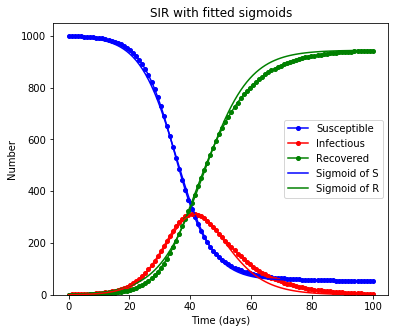

In [59]:

# Total population (N) and number of days (Ndays) of epidemic duration
N = 1000
Ndays=100

# Contact rate, beta, and mean recovery rate, gamma, (in 1/days).
#beta = 0.3
#gamma = 1.0/10

beta = 0.3
gamma = 1/10

# Generating the time array:
t = np.linspace(0, Ndays, Ndays)
dt=t[1]-t[0]

# Initializing the S, I, R arrays
S=np.zeros(Ndays)
I=np.zeros(Ndays)
R=np.zeros(Ndays)
    
# start with one infected individual

S[0]=N
I[0]=1
R[0]=0

# Solving the system of differential equations
for n in range(Ndays-1):
    S[n+1]=S[n]+dt*(-beta*S[n]*I[n]/N)
    I[n+1]=I[n]+dt*(beta*S[n]*I[n]/N - gamma*I[n])
    R[n+1]=R[n]+dt*(gamma*I[n])
        

# parameters for beta=0.2, gamma=1/15   
#alf1=0.11
#alf2=0.09
#DN=55
#t1=53
#t2=67

# parameters for beta=0.3, gamma=1/10   
alf1=0.165
alf2=0.135
DN=55
t1=35.5
t2=44.5

Smod=N-(N-DN)/(1.0+np.exp(-alf1*(t-t1)))
Rmod=(N-DN)/(1.0+np.exp(-alf2*(t-t2)))

fig=plt.figure(figsize=(6,5))
plt.plot(t,S,'bo-',ms=4,label='Susceptible')
plt.plot(t,I,'ro-',ms=4,label='Infectious')
plt.plot(t,R,'go-',ms=4,label='Recovered')

plt.plot(t,Smod,'b-', label='Sigmoid of S')
plt.plot(t,Rmod,'g-', label='Sigmoid of R')
plt.plot(t,N-Smod-Rmod,'r-')
plt.xlabel('Time (days)')
plt.ylabel('Number')
plt.title('SIR with fitted sigmoids')
plt.ylim(0,01.05*N)
plt.legend(loc='center right')
plt.show()




#### References for further reading on this method

•	Multiple Epidemic Wave Model of the COVID-19 Pandemic: Modeling Study, by Kaxiras E, Neofotistos G, J Med Internet Res 2020;22(7):e20912, DOI: 10.2196/20912. PMID: 32692690, PMCID: 7394522

Accessible at: https://www.jmir.org/2020/7/e20912/


•	The first 100 days: Modeling the evolution of the COVID-19 pandemic, by Kaxiras E, Neofotistos G, Angelaki E. The first 100 days: Modeling the evolution of the COVID-19 pandemic. Chaos, Solitons & Fractals 2020 Sep 30;138:110114

Accessible at: https://doi.org/10.1016/j.chaos.2020.110114

•	Modeling the Covid-19 Pandemic Response of the US States, by Neofotistos G, Kaxiras E, medRxiv 2020.06.24.20138982; doi: https://doi.org/10.1101/2020.06.24.20138982
